# Sakila Database Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

In [2]:
conn = sqlite3.connect('sakila.db')

df = pd.read_sql('''
    SELECT
        rental.rental_id, rental.rental_date, rental.return_date,
        customer.last_name AS customer_lastname,
        store.store_id,
        city.city AS rental_store_city,
        film.title AS film_title, film.rental_duration AS film_rental_duration,
        film.rental_rate AS film_rental_rate, film.replacement_cost AS film_replacement_cost,
        film.rating AS film_rating
    FROM rental
    INNER JOIN customer ON rental.customer_id == customer.customer_id
    INNER JOIN inventory ON rental.inventory_id == inventory.inventory_id
    INNER JOIN store ON inventory.store_id == store.store_id
    INNER JOIN address ON store.address_id == address.address_id
    INNER JOIN city ON address.city_id == city.city_id
    INNER JOIN film ON inventory.film_id == film.film_id
    ;
''', conn, index_col='rental_id', parse_dates=['rental_date', 'return_date'])


In [3]:
df.head()

,rental_date,return_date,customer_lastname,store_id,rental_store_city,film_title,film_rental_duration,film_rental_rate,film_replacement_cost,film_rating
rental_id,,,,,,,,,,
1,2005-05-24 22:53:30,2005-05-26 22:04:30,HUNTER,1,Lethbridge,BLANKET BEVERLY,7,2.99,21.99,G
2,2005-05-24 22:54:33,2005-05-28 19:40:33,COLLAZO,2,Woodridge,FREAKY POCUS,7,2.99,16.99,R
3,2005-05-24 23:03:39,2005-06-01 22:12:39,MURRELL,2,Woodridge,GRADUATE LORD,7,2.99,14.99,G
4,2005-05-24 23:04:41,2005-06-03 01:43:41,PURDY,1,Lethbridge,LOVE SUICIDES,6,0.99,21.99,R
5,2005-05-24 23:05:21,2005-06-02 04:33:21,HANSEN,2,Woodridge,IDOLS SNATCHERS,5,2.99,29.99,NC-17


In [4]:
df.shape

(16044, 10)

In [5]:
df.columns #List of column names

Index(['rental_date', 'return_date', 'customer_lastname', 'store_id',
       'rental_store_city', 'film_title', 'film_rental_duration',
       'film_rental_rate', 'film_replacement_cost', 'film_rating'],
      dtype='object')

In [6]:
df.describe() #Summary statistics for numerical columns

,rental_date,return_date,store_id,film_rental_duration,film_rental_rate,film_replacement_cost
count,16044,15861,16044.000000,16044.00000,16044.000000,16044.000000
mean,2005-07-23 08:12:53.217526912,2005-07-25 23:58:03.138768128,1.506171,4.93549,2.942630,20.215443
min,2005-05-24 22:53:30,2005-05-25 23:55:21,1.000000,3.00000,0.990000,9.990000
25%,2005-07-07 00:58:40.500000,2005-07-10 15:49:36,1.000000,4.00000,0.990000,14.990000
50%,2005-07-28 16:04:32.500000,2005-08-01 19:45:29,2.000000,5.00000,2.990000,20.990000
75%,2005-08-17 21:16:23,2005-08-20 23:35:55,2.000000,6.00000,4.990000,25.990000
max,2006-02-14 15:16:03,2005-09-02 02:35:22,2.000000,7.00000,4.990000,29.990000
std,NaN,NaN,0.499978,1.40169,1.649678,6.081771


In [7]:
df.info() # Data types and non-null counts

<class 'pandas.core.frame.DataFrame'>
Index: 16044 entries, 1 to 16049
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   rental_date            16044 non-null  datetime64[ns]
 1   return_date            15861 non-null  datetime64[ns]
 2   customer_lastname      16044 non-null  object        
 3   store_id               16044 non-null  int64         
 4   rental_store_city      16044 non-null  object        
 5   film_title             16044 non-null  object        
 6   film_rental_duration   16044 non-null  int64         
 7   film_rental_rate       16044 non-null  float64       
 8   film_replacement_cost  16044 non-null  float64       
 9   film_rating            16044 non-null  object        
dtypes: datetime64[ns](2), float64(2), int64(2), object(4)
memory usage: 1.3+ MB


# Numerical analysis and visualization

In [8]:
df.columns

Index(['rental_date', 'return_date', 'customer_lastname', 'store_id',
       'rental_store_city', 'film_title', 'film_rental_duration',
       'film_rental_rate', 'film_replacement_cost', 'film_rating'],
      dtype='object')

In [ ]:
# We'll analyze the film_rental_rate column:
# Also find it's mean and median
df["film_rental_rate"].describe()

count    16044.000000
mean         2.942630
std          1.649678
min          0.990000
25%          0.990000
50%          2.990000
75%          4.990000
max          4.990000
Name: film_rental_rate, dtype: float64

In [11]:
df["film_rental_rate"].mean()

2.9426302667663933

In [12]:
df["film_rental_rate"].median()

2.99

<Axes: title={'center': 'Film Rental Rate Distribution'}, ylabel='Frequency'>

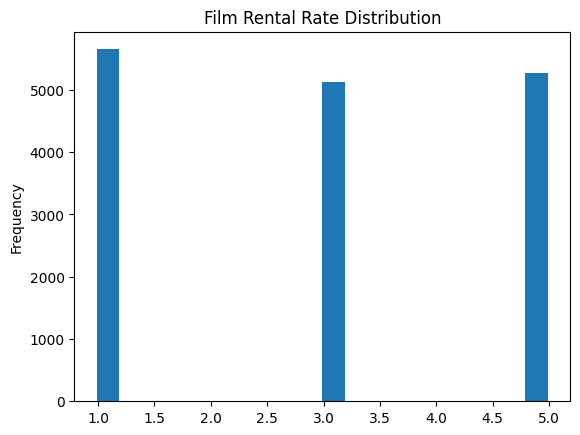

In [13]:
df["film_rental_rate"].plot(kind="hist", bins=20, title="Film Rental Rate Distribution")

<Axes: title={'center': 'Film Rental Rate Box Plot'}>

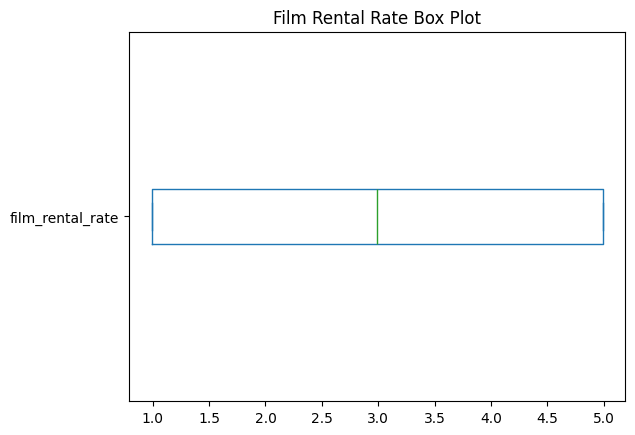

In [17]:
# Via a box and density plot
df["film_rental_rate"].plot(kind="box", vert=False, title="Film Rental Rate Box Plot")

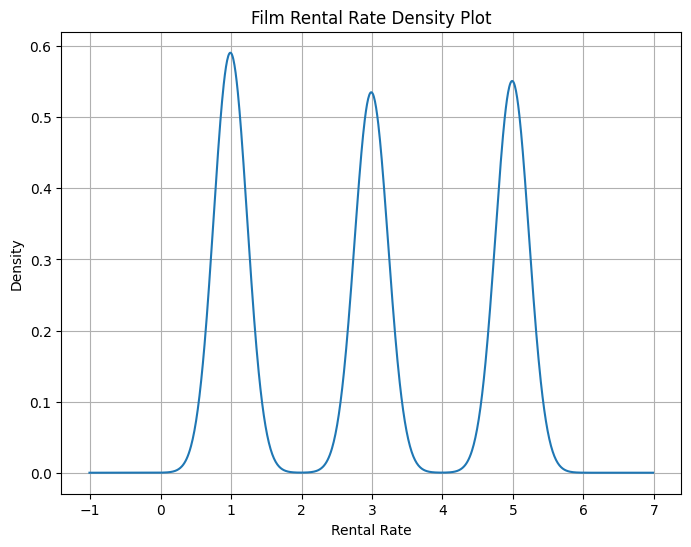

In [19]:
df["film_rental_rate"].plot(kind="density", figsize=(8,6), title="Film Rental Rate Density Plot")
plt.xlabel("Rental Rate")
plt.ylabel("Density")
plt.grid(True)
plt.show()

Text(0, 0.5, 'Number of Films')

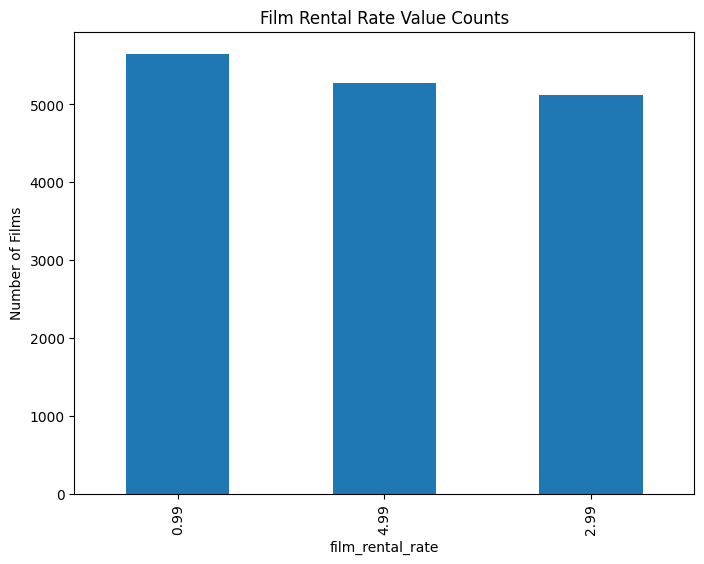

In [ ]:
# Bar plot of value counts
ax = df["film_rental_rate"].value_counts().plot(kind="bar", figsize=(8,6), title="Film Rental Rate Value Counts")
ax.set_ylabel("Number of Films")

# Categorical analysis and visualization

In [22]:
# We'll analyze the rental_store_city column:
df["rental_store_city"].value_counts()

rental_store_city
Woodridge     8121
Lethbridge    7923
Name: count, dtype: int64

<Axes: ylabel='count'>

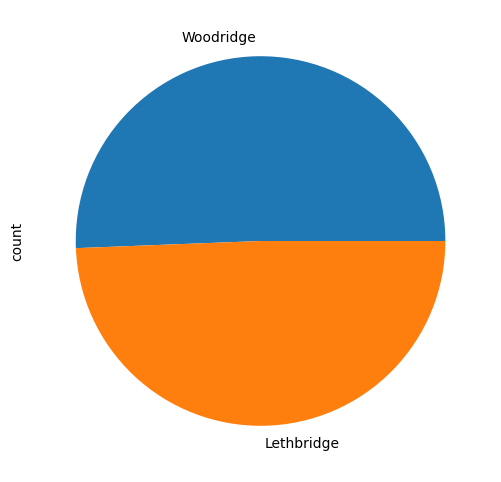

In [23]:
df["rental_store_city"].value_counts().plot(kind="pie", figsize=(8,6))

Text(0, 0.5, 'Number of Rentals')

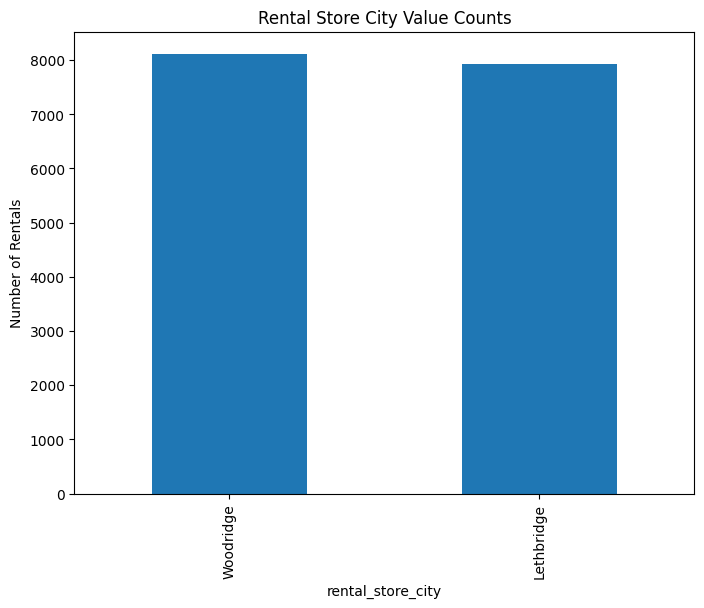

In [25]:
# Bar plot of value counts
ax = df["rental_store_city"].value_counts().plot(kind="bar", figsize=(8,6), title="Rental Store City Value Counts")
ax.set_ylabel("Number of Rentals")

# Column wrangling

In [ ]:
# We can also create new columns or modify existing ones.
# Add and calculate a new rental_rate_return column

# We want to know the rental rate of return of each film. To do that we'll use this formula:

In [27]:
df["rental_gain_return"] = df["film_replacement_cost"] - df["film_rental_rate"] * 100
df["rental_gain_return"].head()

rental_id
1   -277.01
2   -282.01
3   -284.01
4    -77.01
5   -269.01
Name: rental_gain_return, dtype: float64

In [ ]:
# Categorical analysis and visualization
